In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/smart_home_simulated_v7.csv")

df.head()

,ts,deviceId,temp,smoke,gas,power,motion,door,water_flow,isAnomaly,anomalyType
0,2026-02-01 00:00:00,home-01,22.106651,2.968840,5.160722,172.054869,0,0,0.028409,0,NaN
1,2026-02-01 00:01:00,home-01,21.644732,2.442940,4.533092,167.073224,0,0,0.000000,0,NaN
2,2026-02-01 00:02:00,home-01,22.280111,3.954141,5.524114,196.250979,0,0,0.035965,0,NaN
3,2026-02-01 00:03:00,home-01,22.355377,3.961328,6.062623,183.712290,0,0,0.015917,0,NaN
4,2026-02-01 00:04:00,home-01,21.352042,3.918633,5.712498,214.438966,0,0,0.015074,0,NaN


In [2]:
df['ts'] = pd.to_datetime(df['ts'])

df = df.sort_values(['deviceId', 'ts'])

df = df.ffill()

for col in ['smoke', 'gas', 'water_flow']:
    df[col] = df[col].clip(lower=0)

In [3]:
df['hour'] = df['ts'].dt.hour
df['day'] = df['ts'].dt.day
df['dayofweek'] = df['ts'].dt.dayofweek

In [4]:
for col in ['temp', 'smoke', 'gas', 'power', 'water_flow']:
    df[f'{col}_lag1'] = df.groupby('deviceId')[col].shift(1)
    df[f'{col}_lag2'] = df.groupby('deviceId')[col].shift(2)

In [5]:
for col in ['temp', 'smoke', 'gas', 'power', 'water_flow']:
    df[f'{col}_roll_mean'] = df.groupby('deviceId')[col].rolling(5).mean().reset_index(0, drop=True)
    df[f'{col}_roll_std'] = df.groupby('deviceId')[col].rolling(5).std().reset_index(0, drop=True)

In [6]:
df['motion_door'] = df['motion'] * df['door']
df['high_power'] = (df['power'] > 400).astype(int)
df['high_smoke'] = (df['smoke'] > 10).astype(int)

In [7]:
df = df.dropna()

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop(['isAnomaly', 'anomalyType', 'ts', 'deviceId'], axis=1)
y = df['isAnomaly']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [9]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [10]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [11]:
from sklearn.metrics import classification_report, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]
threshold = 0.3 

y_pred = (y_prob > threshold).astype(int)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     51040
           1       0.82      0.90      0.86       506

    accuracy                           1.00     51546
   macro avg       0.91      0.95      0.93     51546
weighted avg       1.00      1.00      1.00     51546

ROC-AUC: 0.9849166196860247


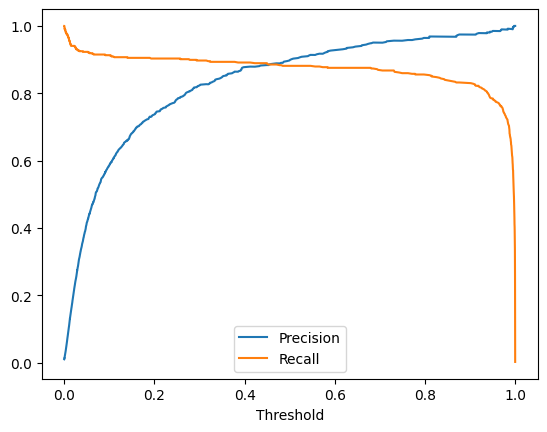

In [12]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.show()

In [13]:
import joblib
import os
os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/xgboost_model.pkl")
joblib.dump(X.columns.tolist(), "../models/features.pkl")
print("Detector saved!")

Detector saved!
